# Lecture 1: Foundations and Gradient Dynamics

### **Recommended Readings**
* [CS231n: Recurrent Neural Networks](https://cs231n.github.io/rnn/)
* [Understanding LSTM Networks (colah's blog)](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
* [Pytorch Tutorial](https://docs.pytorch.org/tutorials/intermediate/char_rnn_classification_tutorial.html)
---

## 0. Comprehensive Literature Summary

| Author (Year) | Architecture / Model | Key Contributions |
| :--- | :--- | :--- |
| **Hochreiter & Schmidhuber (1997)** | **LSTM** | Introduced the Gated Mechanism and Cell State to solve long-term dependency problems. |
| **Pascanu et al. (2013)** | **Gradient Dynamics** | Provided mathematical analysis of vanishing/exploding gradients and proposed solutions like Clipping. |
| **Cho et al. (2014)** | **GRU** | Simplified the LSTM gates for efficiency and established early Seq2Seq concepts. |
| **Sutskever et al. (2014)** | **Seq2Seq (Encoder-Decoder)** | Built a general framework for mapping input-output sequences of different lengths. |
| **Bahdanau et al. (2014)** | **Additive Attention** | Introduced the concept of "aligning" to overcome the fixed-length context vector bottleneck. |
| **Xingjian et al. (2015)** | **ConvLSTM** | Combined LSTMs with Convolutions to process spatiotemporal data (e.g., video, radar). |
---

## 1. Introduction to Sequential Data

### **Limitations of Vanilla Neural Networks**
Traditional neural networks (and Convolutional Networks) have a major limitation: They accept a fixed-sized vector as input (e.g., an image) and produce a fixed-sized vector as output (e.g., probabilities of different classes). Furthermore, these models perform this mapping with a fixed number of computational steps (e.g., the number of layers in the model).

### **The Need for RNNs**
Recurrent Neural Networks are unique because they allow us to operate over **sequences** of vectors: Sequences in the input, the output, or in the most general case both.

### **Generating Synthetic Periodic Data (Sine Wave)**
To illustrate these concepts, we first generate a simple sine wave which will serve as our sequential data.

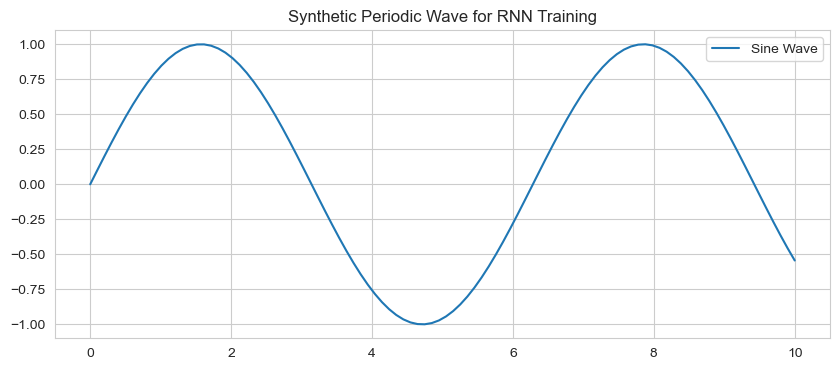

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def generate_periodic_wave(steps=100):
    t = np.linspace(0, 10, steps)
    data = np.sin(t)
    return t, data

t, wave = generate_periodic_wave()
plt.figure(figsize=(10, 4))
plt.plot(t, wave, label='Sine Wave')
plt.title("Synthetic Periodic Wave for RNN Training")
plt.legend()
plt.show()


## 2. Recurrent Neural Network (RNN) Core

### **The Recurrence Formula**
The core of an RNN is a state $h_t$ (hidden vector) that is updated at every time step $t$ by applying a recurrence formula:

$h_t = f_W(h_{t-1}, x_t)$

Specifically, a vanilla RNN uses the following equation:
$h_t = \tanh(W_{hh}h_{t-1} + W_{xh}x_t + b_h)$

* $h_{t-1}$: Hidden state from the previous time step (memory).
* $x_t$: Input vector at the current time step.
* $W_{hh}, W_{xh}$: Weight matrices (parameters) that are **shared across all time steps**.

### **Computational Graph: Unrolling through Time**
An RNN can be thought of as multiple copies of the same network, each passing a message to a successor. This "unrolling" allows the network to process sequences.

---

## 3. Sequential Paradigms & Code Examples

Below are the different architectural variations of RNNs based on the input-output mapping.

### **3.1 One-to-One**
Standard "Vanilla" NN mapping a fixed-sized input to a fixed-sized output.
* **Example:** Predicting a single future value $y$ from a single current value $x$.

```python
# Conceptual mapping: x -> [RNN Cell] -> y
x_input = wave[0]
# y_pred = model(x_input)
```

### **3.2 One-to-Many**
A single input maps to a sequence of outputs.
* **Example:** Image Captioning (Image -> Sequence of words) or generating a wave sequence from a single seed.

```python
seed = wave[0]
generated_wave = []
h = np.zeros((1, 10)) # initial hidden state

for i in range(20):
    # h = tanh(W_hh * h + W_xh * seed)
    # out = W_hy * h
    # generated_wave.append(out)
    # seed = out (feeding the output back as next input)
    pass
```

### **3.3 Many-to-One**
A sequence of inputs maps to a single output.
* **Example:** Sentiment Analysis or predicting the next single value from a history of values.

```python
input_sequence = wave[0:10]
h = np.zeros((1, 10))

for x_t in input_sequence:
    # h = tanh(W_hh * h + W_xh * x_t)
    pass

# final_prediction = W_hy * h
```

### **3.4 Many-to-Many**
Input and output are both sequences.
* **Example:** Part-of-speech tagging (each $x_t$ has a corresponding $y_t$).

```python
input_sequence = wave[0:10]
outputs = []
h = np.zeros((1, 10))

for x_t in input_sequence:
    # h = tanh(W_hh * h + W_xh * x_t)
    # y_t = W_hy * h
    # outputs.append(y_t)
    pass
```

### **3.5 Seq2Seq (Sequence-to-Sequence)**
A special type of many-to-many where the output starts only after the entire input sequence has been processed. This uses an **Encoder-Decoder** architecture.
* **Example:** Machine Translation or multi-step time-series forecasting.

```python
# 1. Encoder Phase
input_seq = wave[0:10]
h_enc = np.zeros((1, 10))
for x_t in input_seq:
    # h_enc = encoder_step(x_t, h_enc)
    pass

# 2. Decoder Phase (Seq2Seq)
h_dec = h_enc # Transfer hidden state (Context Vector)
current_input = input_seq[-1]
predictions = []
for i in range(10):
    # h_dec, out = decoder_step(current_input, h_dec)
    # predictions.append(out)
    # current_input = out
    pass
```

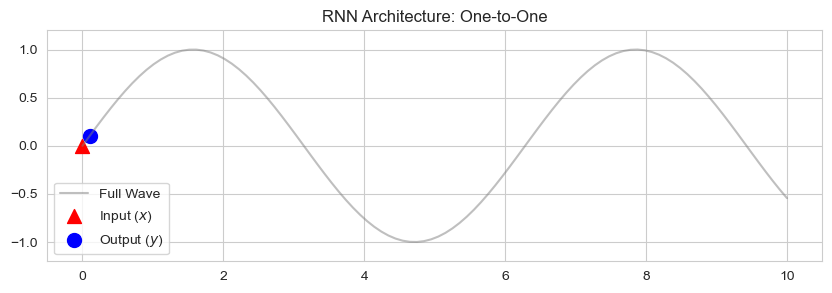

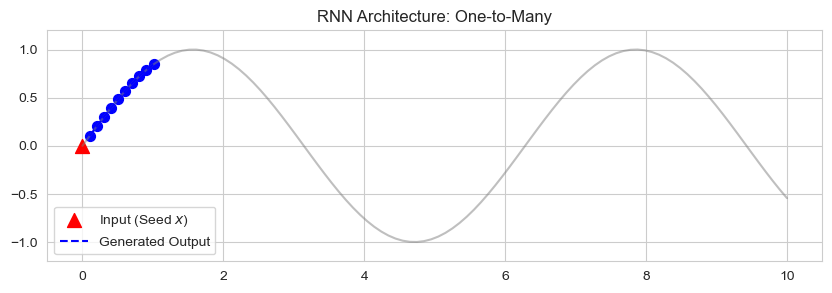

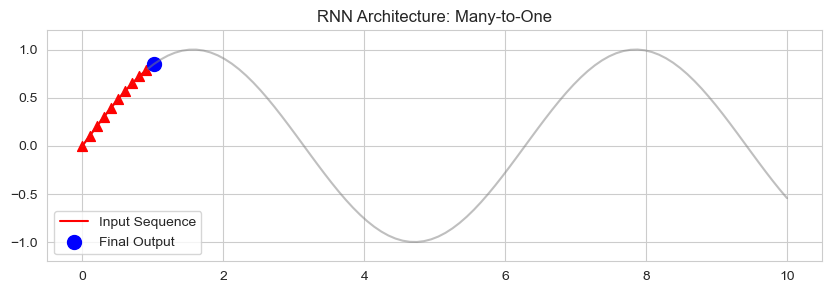

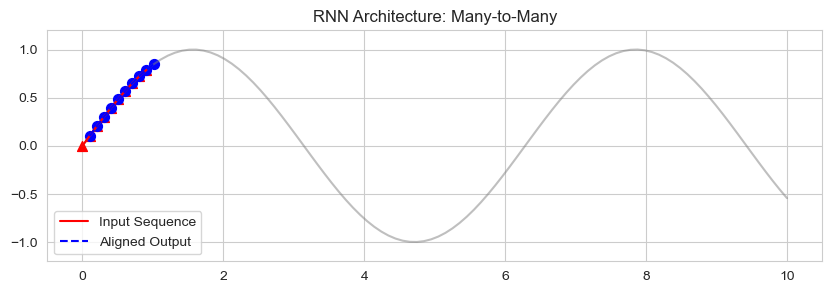

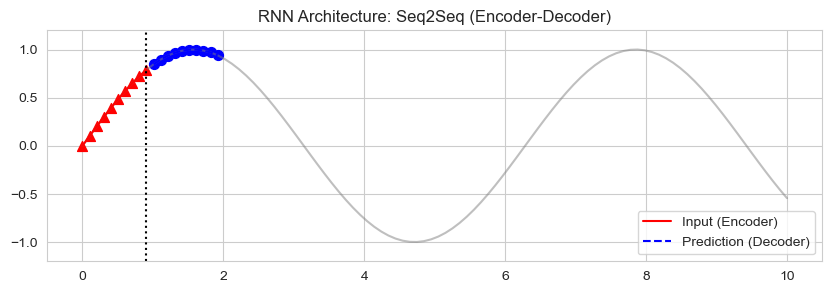

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style to seaborn
sns.set_style("whitegrid")

def generate_periodic_wave(steps=100):
    t = np.linspace(0, 10, steps)
    data = np.sin(t)
    return t, data

# Generate data
t, wave = generate_periodic_wave()

# --- Plot 1: One-to-One ---
plt.figure(figsize=(10, 3))
plt.plot(t, wave, color='gray', alpha=0.5, label='Full Wave')

# Input point (red triangle)
plt.scatter(t[0], wave[0], color='red', marker='^', s=100, label='Input ($x$)')

# Output point (blue circle)
# In this conceptual example, we 'predict' the next point
plt.scatter(t[1], wave[1], color='blue', marker='o', s=100, label='Output ($y$)')

plt.title("RNN Architecture: One-to-One")
plt.legend()
plt.ylim(-1.2, 1.2)
plt.show()


# --- Plot 2: One-to-Many ---
plt.figure(figsize=(10, 3))
plt.plot(t, wave, color='gray', alpha=0.5)

# Input point (red triangle)
plt.scatter(t[0], wave[0], color='red', marker='^', s=100, label='Input (Seed $x$)')

# Generated output sequence (blue line + circles)
# Showing the first 10 generated steps
gen_steps = 10
plt.plot(t[1:1+gen_steps], wave[1:1+gen_steps], color='blue', linestyle='--', label='Generated Output')
plt.scatter(t[1:1+gen_steps], wave[1:1+gen_steps], color='blue', marker='o', s=50)

plt.title("RNN Architecture: One-to-Many")
plt.legend()
plt.ylim(-1.2, 1.2)
plt.show()


# --- Plot 3: Many-to-One ---
plt.figure(figsize=(10, 3))
plt.plot(t, wave, color='gray', alpha=0.5)

# Input sequence (red line + triangles)
input_steps = 10
plt.plot(t[0:input_steps], wave[0:input_steps], color='red', linestyle='-', label='Input Sequence')
plt.scatter(t[0:input_steps], wave[0:input_steps], color='red', marker='^', s=50)

# Single final output (blue circle)
# Predicting the point *after* the input sequence
plt.scatter(t[input_steps], wave[input_steps], color='blue', marker='o', s=100, label='Final Output')

plt.title("RNN Architecture: Many-to-One")
plt.legend()
plt.ylim(-1.2, 1.2)
plt.show()


# --- Plot 4: Many-to-Many ---
plt.figure(figsize=(10, 3))
plt.plot(t, wave, color='gray', alpha=0.5)

# Input sequence (red line + triangles)
input_steps = 10
plt.plot(t[0:input_steps], wave[0:input_steps], color='red', linestyle='-', label='Input Sequence')
plt.scatter(t[0:input_steps], wave[0:input_steps], color='red', marker='^', s=50)

# Output sequence (blue line + circles)
# Conceptual: Each output point is aligned with each input point (e.g., shifted by one)
plt.plot(t[1:1+input_steps], wave[1:1+input_steps], color='blue', linestyle='--', label='Aligned Output')
plt.scatter(t[1:1+input_steps], wave[1:1+input_steps], color='blue', marker='o', s=50)

plt.title("RNN Architecture: Many-to-Many")
plt.legend()
plt.ylim(-1.2, 1.2)
plt.show()


# --- Plot 5: Seq2Seq (Encoder-Decoder Many-to-Many) ---
plt.figure(figsize=(10, 3))
plt.plot(t, wave, color='gray', alpha=0.5)

# Input sequence (Encoder) - (red line + triangles)
input_steps = 10
plt.plot(t[0:input_steps], wave[0:input_steps], color='red', linestyle='-', label='Input (Encoder)')
plt.scatter(t[0:input_steps], wave[0:input_steps], color='red', marker='^', s=50)

# Transfer point (conceptual Context Vector)
# Vertical line showing the split between encoding and decoding
plt.axvline(x=t[input_steps-1], color='black', linestyle=':')
#plt.text(t[input_steps-1], 1.0, 'Context', horizontalalignment='center')

# Predicted sequence (Decoder) - (blue line + circles)
# The sequence starts *after* the input sequence ends
pred_steps = 10
plt.plot(t[input_steps:input_steps+pred_steps], wave[input_steps:input_steps+pred_steps], color='blue', linestyle='--', label='Prediction (Decoder)')
plt.scatter(t[input_steps:input_steps+pred_steps], wave[input_steps:input_steps+pred_steps], color='blue', marker='o', s=50)

plt.title("RNN Architecture: Seq2Seq (Encoder-Decoder)")
plt.legend()
plt.ylim(-1.2, 1.2)
plt.show()

## 3. Training RNNs

### **Backpropagation Through Time (BPTT)**
Training an RNN involves a specific adaptation of backpropagation known as **BPTT**.
* **The Concept**: The error is propagated backwards through the unrolled computational graph. Since the parameters ($W_{hh}$ and $W_{xh}$) are shared across all time steps, the gradient with respect to a parameter is the summation of the gradients at each time step.
* **Chain Rule across Time**: To compute the gradient of the loss $L$ at time $t$ with respect to weights, the model must account for the hidden state's dependence on all previous states.

### **Truncated BPTT**
In practice, computing the full gradient for extremely long sequences (e.g., thousands of steps) is computationally expensive and leads to memory issues.
* **Practical Solution**: We process the sequence in smaller chunks. We perform forward and backward passes only within a fixed number of steps (e.g., 20 or 50), while carrying the hidden state forward to the next chunk to maintain the continuity of the hidden representation.

---

## 4. Gradient Dynamics and Stability

### **The Vanishing and Exploding Gradient Problem**
The difficulty in training RNNs arises from the mathematical structure of the gradient. The term $\frac{\partial h_t}{\partial h_k}$ involves a product of Jacobian matrices:

$$\frac{\partial h_t}{\partial h_k} = \prod_{i=k+1}^{t} \frac{\partial h_i}{\partial h_{i-1}}$$

* **Exploding Gradients**: If the weights are large (specifically, if the largest eigenvalue of the weight matrix is $> 1$), the product grows exponentially. This causes the weights to oscillate or become `NaN`.
* **Vanishing Gradients**: If the weights are small (eigenvalue $< 1$), the gradient shrinks exponentially as it travels back in time. Consequently, the model "forgets" long-term dependencies because the signal from distant time steps becomes too weak to update the weights.



### **Heuristics for Stability**
1. **Gradient Clipping**: A technique where gradients are scaled down if their norm exceeds a certain threshold to prevent exploding gradients.
2. **Proper Initialization**: Initializing the recurrent weights ($W_{hh}$) as an identity matrix or using orthogonal initialization to keep the eigenvalues near 1.

---

## 5. Gated Architectures (The Solution)

Gated RNNs were designed to mitigate the vanishing gradient problem by using internal gates to regulate the flow of information.

### **LSTM (Long Short-Term Memory)**
The core innovation of LSTM is the **Cell State ($c_t$)**, which acts as a "long-term memory" or information highway.
* **Forget Gate**: Decides what information to discard from the cell state.
* **Input Gate**: Decides which values from the current input to update in the cell state.
* **Output Gate**: Determines what part of the cell state should be output as the hidden state $h_t$.
* **Mechanism**: Because the cell state update involves **addition** rather than just matrix multiplication, gradients can flow through the cell state for long periods without vanishing.

### **GRU (Gated Recurrent Unit)**
A streamlined version of the LSTM that merges the forget and input gates into a single "update gate."
* **Reset Gate**: Determines how much of the previous memory to forget.
* **Update Gate**: Determines the balance between the previous state and the new candidate state.
* **Efficiency**: With fewer parameters, GRUs are faster to train and often perform comparably to LSTMs on smaller datasets.

## **6. Practical Implementation: Seq2Seq for Time-Series Forecasting**

### **Model Architecture**
In this implementation, we build a **Sequence-to-Sequence (Seq2Seq)** model designed to predict future values of a sine wave based on its past history.
* **Encoder**: An RNN that processes the input sequence (past values) and compresses the information into a context vector (the final hidden state).
* **Decoder**: An RNN that takes the context vector and predicts the next sequence of values (future values) step-by-step.

### **Data Generation Strategy: Synthetic Irregular Waveform**
To evaluate the model's ability to capture complex non-linear dynamics, we generate an **Irregular Waveform** through the superposition of multiple harmonic components. This approach simulates real-world stochastic signals (e.g., ocean waves or mechanical vibrations) rather than simple periodic curves.

* **Superposition Principle**: The signal is composed of **10 distinct sine waves** ($N=10$) merged into a single time-series.
* **Randomized Parameters**: For each component $i$, parameters are uniformly sampled to ensure spectral complexity:
    * **Amplitude ($A_i$):** $A \sim U(0.5, 1.5)$ — determines the energy of each frequency component.
    * **Frequency ($f_i$):** $f \sim U(0.5, 5.0)$ — creates the irregular, non-periodic appearance.
    * **Phase ($\phi_i$):** $\phi \sim U(0, 2\pi)$ — ensures random alignment of peaks and troughs.
* **Gaussian Noise**: To simulate measurement uncertainty and test the model's robustness, white noise ($\epsilon$) is added with a controllable intensity ($\sigma$).
* **Formula**: 
    $$y(t) = \sum_{i=1}^{10} A_i \sin(f_i t + \phi_i) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$


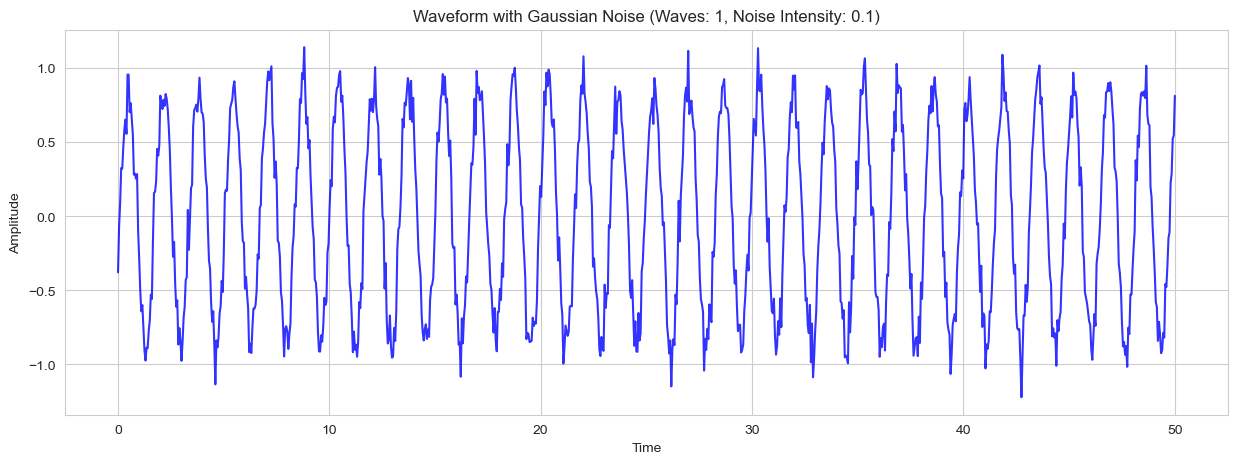

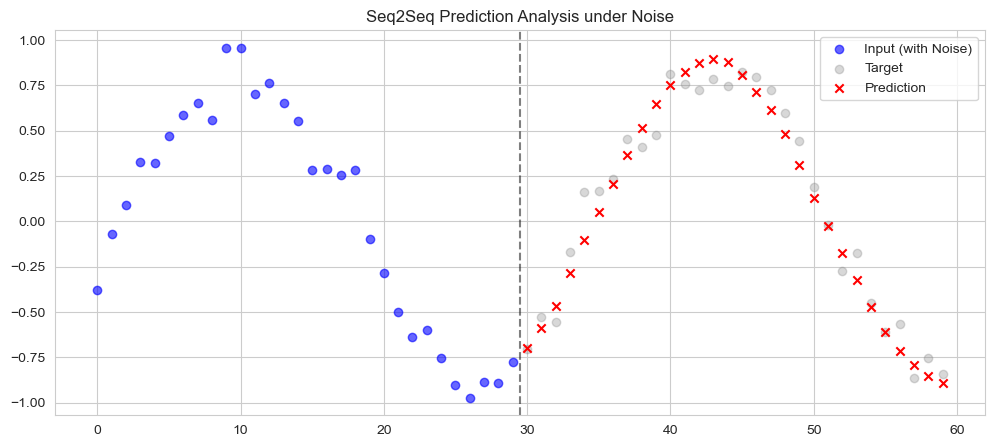

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

np.random.seed(42)
total_steps = 1000
input_len = 30
output_len = 30

t_total = np.linspace(0, 50, total_steps)
combined_wave = np.zeros(total_steps)

nuber_of_waves = 1 # 합성할 파형의 개수(문제의 복잡도))
noise_intensity = 0.1 # 가우시안 노이즈 강도 조절 파라미터

for _ in range(nuber_of_waves):
    amplitude = np.random.uniform(0.5, 1.5)
    phase = np.random.uniform(0, 2 * np.pi)
    frequency = np.random.uniform(0.5, 5.0) 
    combined_wave += amplitude * np.sin(frequency * t_total + phase)

# 가우시안 노이즈 생성 및 추가
noise = np.random.normal(0, noise_intensity, total_steps)
data = (combined_wave + noise).astype(np.float32)

plt.figure(figsize=(15, 5))
plt.plot(t_total, data, color='blue', alpha=0.8)
plt.title(f"Waveform with Gaussian Noise (Waves: {nuber_of_waves}, Noise Intensity: {noise_intensity})")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

X_list = []
Y_list = []
for i in range(len(data) - input_len - output_len):
    X_list.append(data[i : i + input_len])
    Y_list.append(data[i + input_len : i + input_len + output_len])

X = torch.tensor(np.array(X_list)).unsqueeze(-1)
Y = torch.tensor(np.array(Y_list)).unsqueeze(-1)

class Seq2SeqRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Seq2SeqRNN, self).__init__()
        self.hidden_size = hidden_size
        self.encoder = nn.RNN(input_size, hidden_size, batch_first=True)
        self.decoder = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, target_len):
        _, h_n = self.encoder(x)
        decoder_input = x[:, -1, :] 
        outputs = []
        for _ in range(target_len):
            out, h_n = self.decoder(decoder_input.unsqueeze(1), h_n)
            out = self.fc(out)
            outputs.append(out)
            decoder_input = out.squeeze(1)
        return torch.cat(outputs, dim=1)

model = Seq2SeqRNN(input_size=1, hidden_size=64, output_size=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

batch_size = 64
num_batches = len(X) // batch_size

for epoch in range(50):
    model.train()
    epoch_loss = 0
    for i in range(num_batches):
        start = i * batch_size
        end = start + batch_size
        optimizer.zero_grad()
        output = model(X[start:end], output_len)
        loss = criterion(output, Y[start:end])
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

model.eval()
with torch.no_grad():
    sample_idx = 0
    test_input = X[sample_idx:sample_idx+1]
    prediction = model(test_input, output_len)

plt.figure(figsize=(12, 5))
plt.scatter(np.arange(input_len), test_input[0, :, 0], color='blue', label="Input (with Noise)", alpha=0.6)
plt.scatter(np.arange(input_len, input_len + output_len), Y[sample_idx, :, 0], color='gray', label="Target", alpha=0.3)
plt.scatter(np.arange(input_len, input_len + output_len), prediction[0, :, 0], color='red', marker='x', label="Prediction")
plt.axvline(x=input_len - 0.5, color='black', linestyle='--', alpha=0.5)
plt.title("Seq2Seq Prediction Analysis under Noise")
plt.legend()
plt.show()

## **7. Teacher Forcing Mechanism**

In Seq2Seq models, the decoder is an autoregressive structure that uses its own prediction at time $t$ as the input for time $t+1$. This can lead to specific challenges during the training phase.

### The Problem: Exposure Bias
* During the early stages of training, the decoder is likely to produce incorrect predictions ($\hat{y}_t$).
* Since $\hat{y}_t$ is fed as the next input, a single error can propagate and compound throughout the sequence.
* This leads to unstable training and slow convergence, as the model struggles to recover from its own mistakes.

### The Solution: Teacher Forcing
* **Teacher Forcing** is a strategy where the **ground truth ($y_t$)** from the training dataset is used as the next input instead of the model's own predicted output.
* It acts like a teacher guiding a student by providing the correct word/value at each step, ensuring the model stays on the "right track."

| Figure 1. Without Teacher Forcing | Figure 2. With Teacher Forcing |
| :---: | :---: |
| 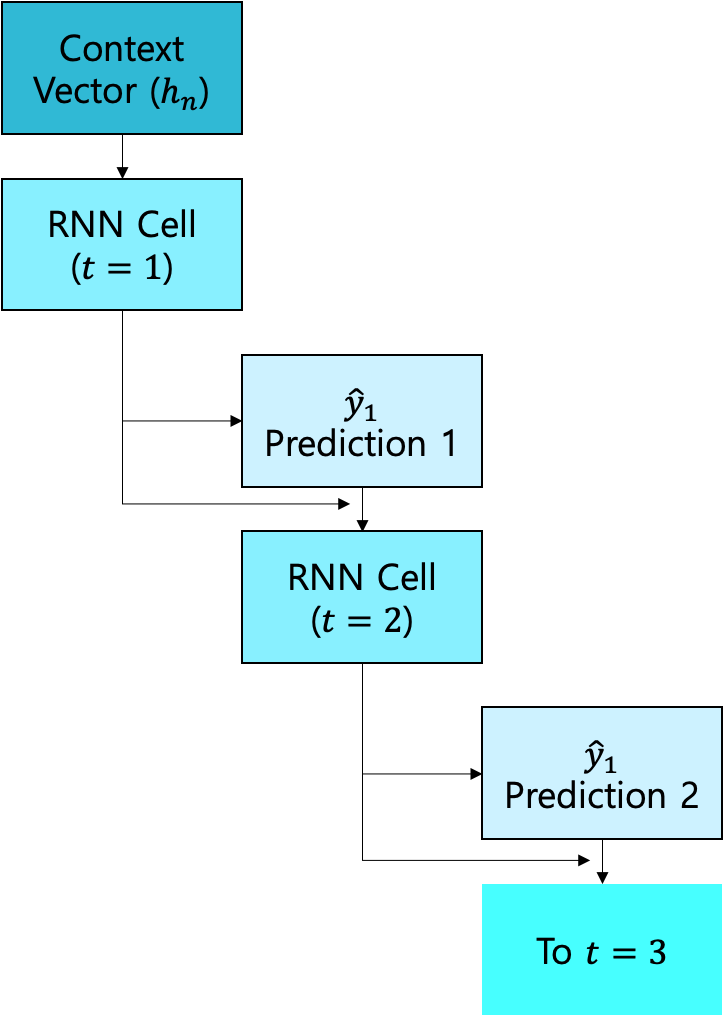 | 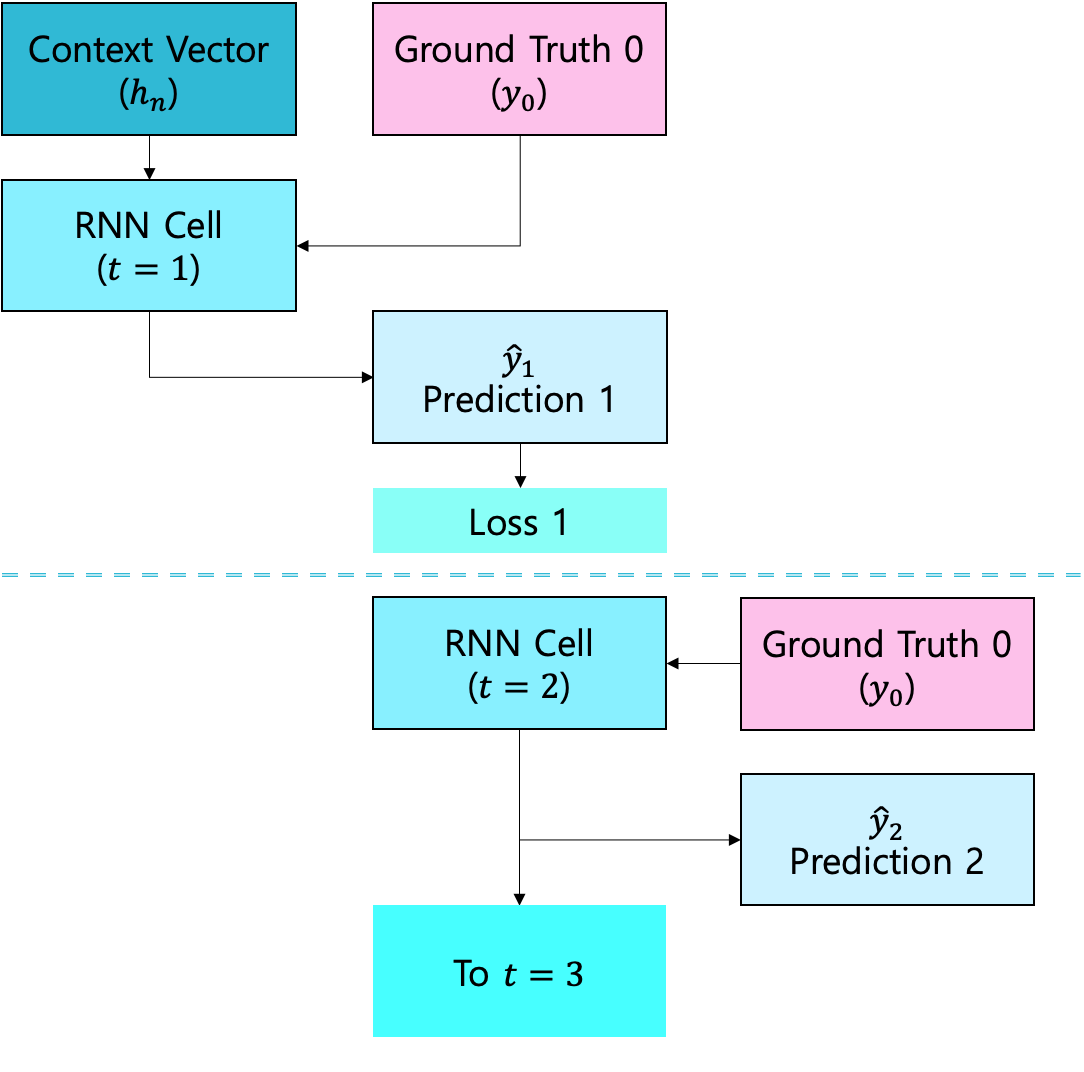 |
| *Self-Generation (Inference)* | *Ground Truth Injection (Training)* |

### Scheduled Sampling (Teacher Forcing Ratio)
* **Training:** We use a `teacher_forcing_ratio` to decide whether to feed the ground truth or the model's prediction. 
    * Ratio = 1.0: Always use ground truth.
    * Ratio = 0.0: Always use the model's own prediction (same as inference).
* **Inference:** At test time, the ratio is always **0.0**, as ground truth is unavailable.
* **Trade-off:** While high ratios speed up training, they can cause a gap between training and testing behaviors. Gradually reducing the ratio during training is a common technique known as **Scheduled Sampling**.

Training Model without Teacher Forcing...
Training Model with Teacher Forcing...


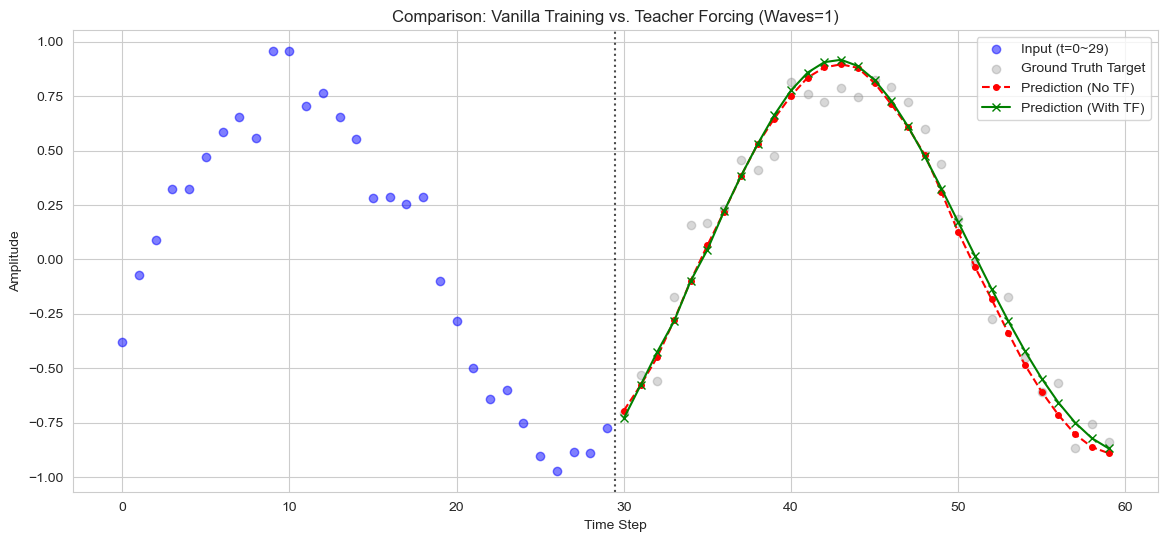

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

sns.set_style("whitegrid")

# 1. Data Generation
np.random.seed(42)
total_steps = 1000
input_len = 30
output_len = 30

t_total = np.linspace(0, 50, total_steps)
combined_wave = np.zeros(total_steps)

nuber_of_waves = 1 
noise_intensity = 0.1 

for _ in range(nuber_of_waves):
    amplitude = np.random.uniform(0.5, 1.5)
    phase = np.random.uniform(0, 2 * np.pi)
    frequency = np.random.uniform(0.5, 5.0) 
    combined_wave += amplitude * np.sin(frequency * t_total + phase)

noise = np.random.normal(0, noise_intensity, total_steps)
data = (combined_wave + noise).astype(np.float32)

X_list, Y_list = [], []
for i in range(len(data) - input_len - output_len):
    X_list.append(data[i : i + input_len])
    Y_list.append(data[i + input_len : i + input_len + output_len])

X = torch.tensor(np.array(X_list)).unsqueeze(-1)
Y = torch.tensor(np.array(Y_list)).unsqueeze(-1)

# 2. Model Definition with Teacher Forcing Capability
class Seq2SeqRNN_TF(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Seq2SeqRNN_TF, self).__init__()
        self.hidden_size = hidden_size
        self.encoder = nn.RNN(input_size, hidden_size, batch_first=True)
        self.decoder = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, target_y=None, tf_ratio=0.0):
        batch_size = x.shape[0]
        target_len = target_y.shape[1] if target_y is not None else output_len
        
        _, h_n = self.encoder(x)
        decoder_input = x[:, -1, :] 
        outputs = []

        for t in range(target_len):
            out, h_n = self.decoder(decoder_input.unsqueeze(1), h_n)
            out = self.fc(out)
            outputs.append(out)
            
            # Determine next input: Teacher Forcing vs. Self-Gen
            if target_y is not None and random.random() < tf_ratio:
                decoder_input = target_y[:, t, :]  # Teacher Forcing
            else:
                decoder_input = out.squeeze(1)     # Self-Generated
                
        return torch.cat(outputs, dim=1)

# 3. Training Function
def train_model(model, tf_ratio, epochs=50):
    optimizer = optim.Adam(model.parameters(), lr=0.005)
    criterion = nn.MSELoss()
    batch_size = 64
    num_batches = len(X) // batch_size
    
    for epoch in range(epochs):
        model.train()
        for i in range(num_batches):
            start, end = i * batch_size, (i + 1) * batch_size
            optimizer.zero_grad()
            output = model(X[start:end], Y[start:end], tf_ratio=tf_ratio)
            loss = criterion(output, Y[start:end])
            loss.backward()
            optimizer.step()
    return model

# 4. Comparative Experiment
# Model A: No Teacher Forcing
model_no_tf = Seq2SeqRNN_TF(1, 64, 1)
print("Training Model without Teacher Forcing...")
model_no_tf = train_model(model_no_tf, tf_ratio=0.0)

# Model B: With Teacher Forcing (50% ratio)
model_with_tf = Seq2SeqRNN_TF(1, 64, 1)
print("Training Model with Teacher Forcing...")
model_with_tf = train_model(model_with_tf, tf_ratio=0.5)

# 5. Visualization
model_no_tf.eval()
model_with_tf.eval()

with torch.no_grad():
    sample_idx = 0
    test_input = X[sample_idx:sample_idx+1]
    
    # Inference (Always tf_ratio=0.0 for testing)
    pred_no_tf = model_no_tf(test_input, tf_ratio=0.0)
    pred_with_tf = model_with_tf(test_input, tf_ratio=0.0)

plt.figure(figsize=(14, 6))

# Input and Target
plt.scatter(np.arange(input_len), test_input[0, :, 0], color='blue', label="Input (t=0~29)", alpha=0.5)
plt.scatter(np.arange(input_len, input_len + output_len), Y[sample_idx, :, 0], color='gray', label="Ground Truth Target", alpha=0.3)

# Predictions
plt.plot(np.arange(input_len, input_len + output_len), pred_no_tf[0, :, 0].numpy(), 
         color='red', linestyle='--', marker='o', markersize=4, label="Prediction (No TF)")
plt.plot(np.arange(input_len, input_len + output_len), pred_with_tf[0, :, 0].numpy(), 
         color='green', linestyle='-', marker='x', markersize=6, label="Prediction (With TF)")

plt.axvline(x=input_len - 0.5, color='black', linestyle=':', alpha=0.7)
plt.title(f"Comparison: Vanilla Training vs. Teacher Forcing (Waves={nuber_of_waves})")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.legend()
plt.show()